# Inteligencia Artificial 2026 - Lab 03

En este laboratorio vamos a diseñar redes neuronales *fully connected* en la librería `tensorflow.keras` para un problema de clasificación y un problema de regresión.

In [2]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.1.2-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.78.0-cp313-cp313-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using c


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Cindy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn
from sklearn.datasets import load_digits, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, mean_absolute_error, r2_score

# TensorFlow y Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Configuración de estilo para gráficas
sns.set_theme(style="whitegrid")

### Ejercicio 1: Clasificación de Dígitos (Scikit-Learn digits)
Este ejercicio se centra en entender cómo una red neuronal "ve" patrones espaciales aplanados.

**Dataset:** `sklearn.datasets.load_digits()` contiene 1,797 muestras, 64 atributos.

**Objetivo:** Configurar la capa de salida y la función de pérdida para clasificación multiclase (10 dígitos).

**Instrucciones:**
* Normalizar los datos dividiendo por 16 (el valor máximo de los píxeles). Debe explicar las transformaciones que se están haciendo tanto al conjunto de datos, como a las etiquetas.

In [9]:
# Carga de datos
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

# Partición de datos 
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42, stratify=y_digits
)

# 1. Normalización de los datos de entrada
X_train_d_norm = X_train_d / 16.0
X_test_d_norm = X_test_d / 16.0

# 2. Transformación de las etiquetas (One-Hot Encoding)
y_train_d_cat = to_categorical(y_train_d, num_classes=10)
y_test_d_cat = to_categorical(y_test_d, num_classes=10)

**Explicación de Transformaciones:**
* **Conjunto de datos (X):** Las imágenes originales tienen valores de píxeles que van de 0 a 16. Al dividir todo entre 16, normalizamos los datos a un rango de [0, 1]. Esto ayuda a que los gradientes durante el entrenamiento sean estables y la red neuronal converja más rápido.
* **Etiquetas (y):** Las etiquetas originales son enteros del 0 al 9. Se aplicó una transformación *One-Hot Encoding* (usando `to_categorical`), convirtiendo cada entero en un vector de tamaño 10 donde solo hay un '1' en la posición correspondiente a la clase, y '0' en el resto. Esto es necesario porque la capa de salida de nuestra red utilizará la función de activación Softmax para predecir probabilidades independientes para cada una de las 10 clases.
---


* Diseñar una arquitectura con al menos 2 capas ocultas. En cada capa, utilizar las funciones de activación adecuadas. Justifique la elección del número de capas y de neuronas, así como de las funciones de activación.

In [10]:
model_digits = Sequential([
    Dense(64, activation='relu', input_shape=(64,)), 
    Dense(32, activation='relu'),                    
    Dense(10, activation='softmax')                  
])

model_digits.summary()

C:\Users\Cindy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,570 (25.66 KB)

 Trainable params: 6,570 (25.66 KB)

 Non-trainable params: 0 (0.00 B)

**Justificación de la Arquitectura:**
* **Capas y Neuronas:** Se eligieron 2 capas ocultas. La primera con 64 neuronas (coincidiendo con los 64 atributos de entrada para capturar características iniciales) y una segunda de 32 neuronas para comprimir la representación aprendida (reducción de dimensionalidad progresiva). La capa de salida tiene exactamente 10 neuronas porque el objetivo es clasificar 10 dígitos distintos.
* **Funciones de Activación:** En las capas ocultas se utilizó **ReLU**, ya que mitiga el problema del desvanecimiento del gradiente y permite un entrenamiento más rápido. En la capa de salida se utilizó **Softmax**, obligatoria para problemas de clasificación multiclase, ya que transforma las salidas en una distribución de probabilidades que suman 1.
---

* Elegir la función de pérdida apropiada, así como los hiper-parámetros que considere más adecuados. Justifique la elección de estos hiper-parámetros.

In [11]:
model_digits.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history_digits = model_digits.fit(
    X_train_d_norm, y_train_d_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.1, 
    verbose=1
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3171 - loss: 2.1164 - val_accuracy: 0.5208 - val_loss: 1.8528
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6744 - loss: 1.5368 - val_accuracy: 0.7569 - val_loss: 1.2125
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8360 - loss: 0.9014 - val_accuracy: 0.8889 - val_loss: 0.6830
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9041 - loss: 0.5254 - val_accuracy: 0.9236 - val_loss: 0.4446
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9250 - loss: 0.3652 - val_accuracy: 0.9444 - val_loss: 0.3355
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9428 - loss: 0.2842 - val_accuracy: 0.9097 - val_loss: 0.3042
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9528 - loss: 0.2327 - val_accuracy: 0.9306 - val_loss: 0.2556
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9582 - loss: 0.1991 - val_accuracy: 0.9375 - val_loss:

**Justificación de Hiper-parámetros:**
* **Función de pérdida:** Se utilizó `categorical_crossentropy` porque es la estándar matemática para clasificación multiclase con etiquetas en formato One-Hot. Penaliza fuertemente predicciones con alta confianza hacia la clase incorrecta.
* **Optimizador y Learning Rate:** Se utilizó **Adam** con un *learning rate* de $\alpha = 0.001$. Adam combina las ventajas de AdaGrad y RMSProp, ajustando dinámicamente el ratio de aprendizaje. 0.001 es el valor inicial recomendado por defecto que suele ofrecer buena convergencia.
* **Epochs y Batch Size:** Se fijaron 50 *epochs*, suficientes para que este dataset pequeño converja. El *batch size* se fijó en 32, ofreciendo un buen equilibrio entre uso de memoria, velocidad y regularización del gradiente estocástico.
---

* Mostrar una Matriz de Confusión usando seaborn para identificar qué números confunde la red (comúnmente debería ser el 1 con el 7 o el 3 con el 8).


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


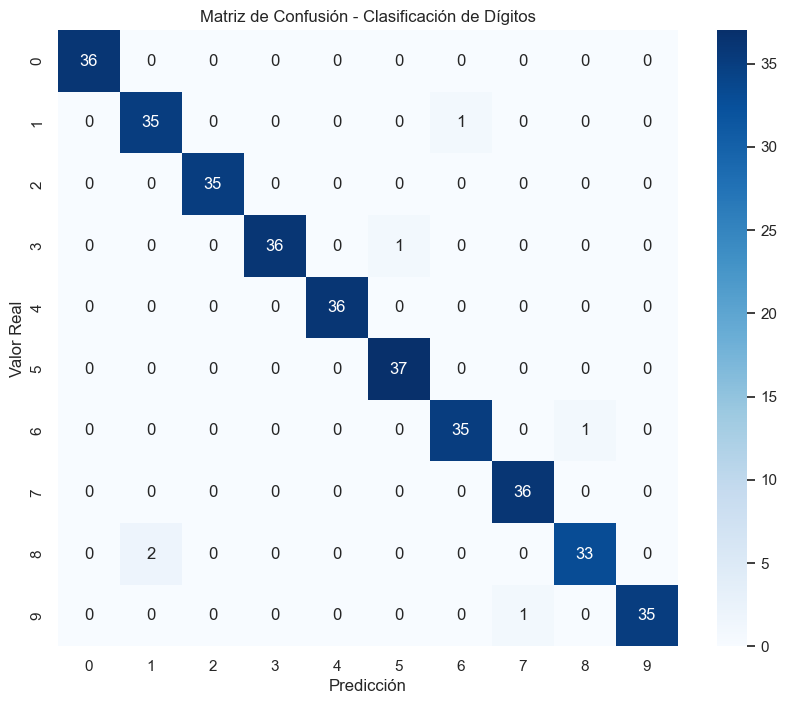

In [ ]:
y_pred_d_probs = model_digits.predict(X_test_d_norm)
y_pred_d_classes = np.argmax(y_pred_d_probs, axis=1)

cm = confusion_matrix(y_test_d, y_pred_d_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.title('Matriz de Confusión - Clasificación de Dígitos')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

* Muestre un conjunto de métricas de desempeño (tanto en entrenamiento como en test), para determinar la efectividad de su clasificador. Muestre 5 ejemplos de imágenes bien clasificadas y 5 ejemplos de imágenes mal clasificadas.

Métricas en Entrenamiento -> Pérdida: 0.0170, Exactitud (Accuracy): 0.9965
Métricas en Prueba (Test) -> Pérdida: 0.0695, Exactitud (Accuracy): 0.9833

Reporte de Clasificación (Test):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      0.97      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      0.97      0.99        37
           4       1.00      1.00      1.00        36
           5       0.97      1.00      0.99        37
           6       0.97      0.97      0.97        36
           7       0.97      1.00      0.99        36
           8       0.97      0.94      0.96        35
           9       1.00      0.97      0.99        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



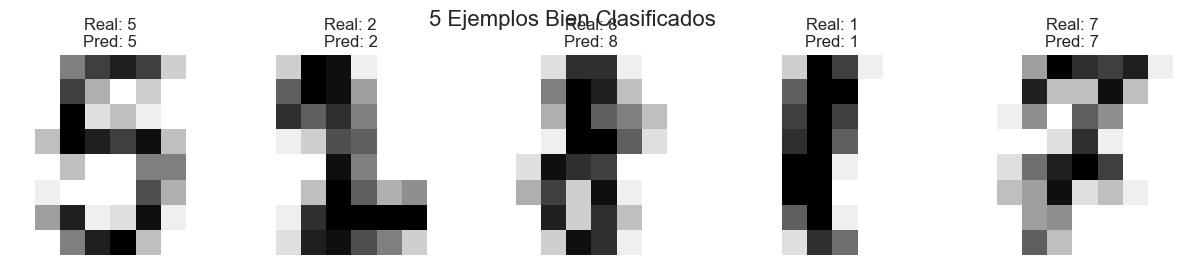

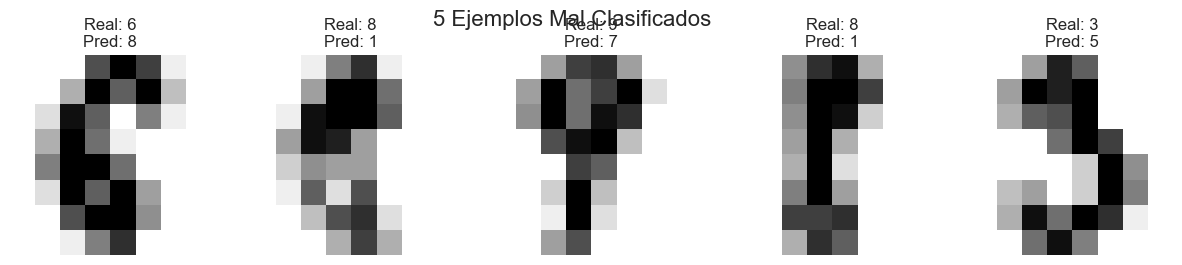

In [13]:
train_loss, train_acc = model_digits.evaluate(X_train_d_norm, y_train_d_cat, verbose=0)
test_loss, test_acc = model_digits.evaluate(X_test_d_norm, y_test_d_cat, verbose=0)

print(f"Métricas en Entrenamiento -> Pérdida: {train_loss:.4f}, Exactitud (Accuracy): {train_acc:.4f}")
print(f"Métricas en Prueba (Test) -> Pérdida: {test_loss:.4f}, Exactitud (Accuracy): {test_acc:.4f}\n")
print("Reporte de Clasificación (Test):\n", classification_report(y_test_d, y_pred_d_classes))


correct_indices = np.where(y_pred_d_classes == y_test_d)[0]
incorrect_indices = np.where(y_pred_d_classes != y_test_d)[0]

# Función para graficar ejemplos
def plot_examples(indices, title):
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(title, fontsize=16)
    for i, ax in enumerate(axes):
        if i < len(indices):
            idx = indices[i]
            image = X_test_d[idx].reshape(8, 8) 
            ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
            ax.set_title(f"Real: {y_test_d[idx]}\nPred: {y_pred_d_classes[idx]}")
        ax.axis('off')
    plt.show()

# Mostrar 5 bien y 5 mal clasificadas
plot_examples(correct_indices[:5], "5 Ejemplos Bien Clasificados")
plot_examples(incorrect_indices[:5], "5 Ejemplos Mal Clasificados")

## Ejercicio 2: Regresión de Precios (Scikit-Learn california_housing)
Este ejercicio se centra en construir un modelo de regresión mediante una red neuronal densa.

**Dataset:** `sklearn.datasets.fetch_california_housing()`

**Objetivo:** Manejo de escalas heterogéneas y métricas de error continuo.

**Instrucciones:**
* Estandarizar los datos (Escalamiento Obligatorio). Usar StandardScaler en los datos de entrada. Sin esto, la red tardará demasiado en converger o los gradientes explotarán.

In [14]:
# Cargar daros
housing = fetch_california_housing()
X_house = housing.data
y_house = housing.target


X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42
)
# Estandarización
scaler = StandardScaler()
X_train_h_scaled = scaler.fit_transform(X_train_h)
X_test_h_scaled = scaler.transform(X_test_h)

**Explicación de la Estandarización:**
 Al usar `StandardScaler`, transformamos las distribuciones para que tengan una media de 0 y desviación estándar de 1. 
 Esto es vital en redes neuronales porque si un atributo tiene valores en los miles y otro en decimales, los pesos de la red oscilarán bruscamente, causando que los gradientes exploten o que el algoritmo de optimización jamás logre converger al mínimo de la función de pérdida.

---

* Probar una red más profunda (ej. 3 capas: 64, 32, 16 o similar) dada la complejidad de los datos socioeconómicos. Justificar la elección de su arquitectura.

In [15]:
model_housing = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_h_scaled.shape[1],)), 
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear') 
])

model_housing.summary()

C:\Users\Cindy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

**Justificación de Arquitectura:**
* **Capas:** Se utilizan 3 capas ocultas (64, 32, 16). Los datos socioeconómicos presentan relaciones fuertemente no lineales y complejas para determinar un precio. Una red más profunda permite extraer jerarquías de características latentes más abstractas.
* **Activación:** Se mantiene ReLU para las capas ocultas por eficiencia. La capa de salida tiene 1 sola neurona con activación Lineal (o sin activación explícita), ya que en un problema de regresión necesitamos predecir un valor continuo que puede tomar cualquier rango (en este caso, el precio de la casa en cientos de miles de dólares).
---

* Elegir la función de pérdida apropiada (ej. MSE o MAE) y usar un optimizador Adam. Justifique la elección de sus hiper-parámetros.

In [16]:
model_housing.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='mse', 
    metrics=['mae'] 
)

history_housing = model_housing.fit(
    X_train_h_scaled, y_train_h,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    verbose=0 
)

**Justificación de Hiper-parámetros:**
* **Función de pérdida:** Se escogió **MSE (Error Cuadrático Medio)** porque castiga de manera cuadrática los errores grandes, obligando al modelo a no equivocarse drásticamente en los precios de las casas.
* **Optimizador:** **Adam** con $\alpha = 0.005$. Dado que hay más capas y datos, un learning rate ligeramente modificado ayuda a sortear mínimos locales.
* **Batch Size y Epochs:** Al ser un dataset con más de 20,000 registros, un batch size de 64 procesa la información en bloques eficientes. Se entrenó por 100 *epochs* asumiendo que un dataset más complejo requiere más iteraciones para el descenso del gradiente.

---

* Mostrar un Generar un Scatter-Plot de Predicciones vs. Valores Reales.

Muestre un conjunto de métricas de desempeño (tanto en entrenamiento como en test), para determinar la efectividad de su regresión. Elabore 3 ejemplos de predicción con su modelo de regresión para 3 observaciones nuevas (que no son parte del dataset).

516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step
Métricas en Entrenamiento:
MSE: 0.2083
MAE: 0.3133
R2 Score: 0.8442

Métricas en Prueba (Test):
MSE: 0.2816
MAE: 0.3553
R2 Score: 0.7851



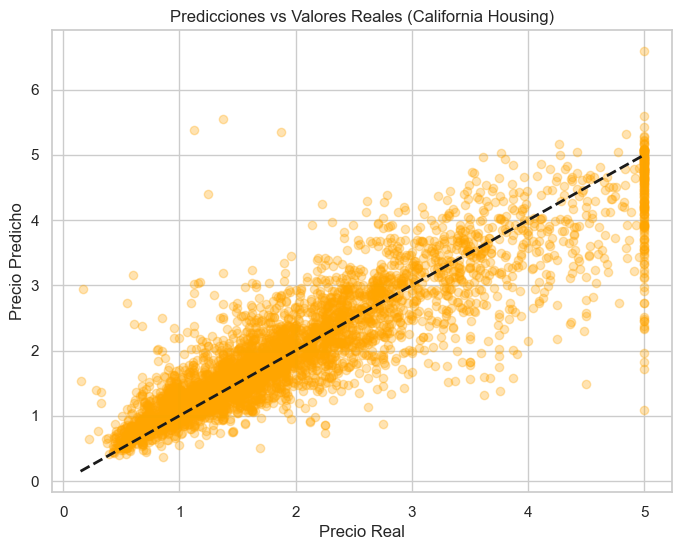

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicciones para 3 observaciones nuevas:
Casa nueva 1 -> Precio estimado: $230,019.69
Casa nueva 2 -> Precio estimado: $51,344.88
Casa nueva 3 -> Precio estimado: $392,935.94


In [17]:
# Predicciones
y_pred_h_train = model_housing.predict(X_train_h_scaled)
y_pred_h_test = model_housing.predict(X_test_h_scaled)

# Métricas
print("Métricas en Entrenamiento:")
print(f"MSE: {mean_squared_error(y_train_h, y_pred_h_train):.4f}")
print(f"MAE: {mean_absolute_error(y_train_h, y_pred_h_train):.4f}")
print(f"R2 Score: {r2_score(y_train_h, y_pred_h_train):.4f}\n")

print("Métricas en Prueba (Test):")
print(f"MSE: {mean_squared_error(y_test_h, y_pred_h_test):.4f}")
print(f"MAE: {mean_absolute_error(y_test_h, y_pred_h_test):.4f}")
print(f"R2 Score: {r2_score(y_test_h, y_pred_h_test):.4f}\n")

# Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_h, y_pred_h_test, alpha=0.3, color='orange')
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'k--', lw=2)
plt.title('Predicciones vs Valores Reales (California Housing)')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.show()

nuevas_casas = np.array([
    [5.0, 25.0, 6.0, 1.0, 1000.0, 3.0, 37.5, -122.0], # Casa en zona central, estándar
    [1.5, 40.0, 3.0, 1.2, 500.0, 4.0, 36.0, -119.0],  # Ingreso bajo, casa antigua
    [8.0, 10.0, 8.0, 1.5, 2000.0, 2.5, 34.0, -118.0]  # Ingreso alto, casa nueva, muchas hab
])

nuevas_casas_scaled = scaler.transform(nuevas_casas)
predicciones_nuevas = model_housing.predict(nuevas_casas_scaled)

print("Predicciones para 3 observaciones nuevas:")
for i, pred in enumerate(predicciones_nuevas):
    print(f"Casa nueva {i+1} -> Precio estimado: ${pred[0]*100000:,.2f}")